# Lab 3: Causal Price Elasticity Estimation

This notebook is self-contained. It loads the data directly from HuggingFace.

## The Research Question

How does a change in price affect the quantity sold? This is the central question of demand analysis. It sounds simple, but answering it from observational data is difficult because prices and quantities are jointly determined. Products that sell more tend to have higher visibility, attract more reviews, and may command higher prices. At the same time, sellers often discount products that are not selling well. Both mechanisms create a correlation between price and quantity that does not reflect the causal effect of price on demand.

## The Causal Model

We work with the following structural equation model (SEM)

**Assumption (SEM).** At each period $t$, the data are generated by
$$Q_{it} = A_{it} \cdot P_{it} + q_t(S_{it}, \varepsilon_{it}),$$
$$P_{it} = p_t(S_{it}, \varepsilon_{it}^p),$$
$$S_{it} = s_t(S_{i,t-1}, \varepsilon_{it}^s).$$
The state vector $S_{it} = (Q_{i,t-1}, P_{i,t-1}, X_{it})$ contains lagged outcomes and product characteristics $X_{it}$.

The term $A_{it} = a_t(S_{it}, \varepsilon_{it})$ is the price sensitivity. It can vary across products and over time. The potential outcome of product $i$ in period $t$ at price $p$ is
$$Q_{it}(p) = A_{it} \cdot p + q_t(S_{it}, \varepsilon_{it}).$$

**Causal parameters.** The conditional average causal effect (CACE) is the expected marginal effect of price given the current state:
$$\alpha_t(S_{it}) = E[A_{it} \mid S_{it}] = E\!\left[\frac{\partial Q_{it}(p)}{\partial p} \,\Big|\, S_{it}\right].$$
The average causal effect (ACE) integrates over the state distribution:
$$\alpha_t = E[A_{it}].$$
In this notebook we estimate the ACE, treating the effect as homogeneous. Heterogeneous effects are left for future labs.

## Identification via Double Machine Learning

Direct regression of $Q_{it}$ on $P_{it}$ is biased because unobserved demand shocks $\varepsilon_{it}$ affect both variables. The key insight is that once we condition on the state $S_{it}$, the Markovian structure of the SEM implies that the residual price variation $P_{it}^\perp = P_{it} - E[P_{it} \mid S_{it}]$ is independent of the error in the quantity equation. Formally, $E[\varepsilon_{it} \cdot P_{it}^\perp \mid S_{it}] = 0$.

This motivates the **partially linear regression (PLR)** model,
$$Q_{it} = \theta \cdot P_{it} + \gamma_t(S_{it}) + u_{it}, \qquad E[u_{it} \mid S_{it}, P_{it}^\perp] = 0,$$
where $\gamma_t(S_{it})$ is a flexible control function that absorbs the confounding variation. The coefficient $\theta$ identifies the ACE $\alpha_t$.

We estimate the PLR using the **double machine learning (DML)** approach of Chernozhukov et al. (2018). The idea is to partial out the state from both $Q_{it}$ and $P_{it}$ using machine learning, and then regress the outcome residual on the treatment residual:
$$Q_{it}^\perp = \theta \cdot P_{it}^\perp + e_{it},$$
where $Q_{it}^\perp = Q_{it} - E[Q_{it} \mid S_{it}]$ and $P_{it}^\perp = P_{it} - E[P_{it} \mid S_{it}]$.

The resulting estimator is
$$\hat{\theta} = \frac{\sum_i \hat{P}_{it}^\perp \hat{Q}_{it}^\perp}{\sum_i (\hat{P}_{it}^\perp)^2},$$
which is consistent and asymptotically normal under mild regularity conditions, even when the nuisance functions are estimated by machine learning.

**No cross-fitting.** The standard DML implementation uses $k$-fold cross-fitting to avoid overfitting bias in the nuisance estimates. Here we use the train/test split provided with the dataset instead. Nuisance models are trained on the training set and residuals are computed on the test set. The causal estimate $\hat{\theta}$ is then obtained from the test-set residuals only. This achieves the same purpose as cross-fitting without requiring repeated model training.

In [1]:
import re
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances, r2_score

palette = sns.color_palette("colorblind")
confidence_level = 0.90

## 1. Load Data

In [2]:
ds = datasets.load_dataset("janteichertkluge/demand-analysis-repro")
df_train = ds["train"].to_pandas()
df_test  = ds["test"].to_pandas()


print(f"Train: {df_train.shape}  |  Test: {df_test.shape}")

Train: (38146, 75)  |  Test: (38041, 75)


## 2. Construct Embedding Features

In [3]:
emb_cols = sorted([c for c in df_train.columns if c.startswith("emb_")])

emb_tr = df_train[emb_cols].values.astype(float)
emb_te = df_test[emb_cols].values.astype(float)

global_mean = emb_tr.mean(axis=0)
emb_tr_n = normalize(emb_tr - global_mean, axis=1)
emb_te_n = normalize(emb_te - global_mean, axis=1)

pca = PCA(n_components=5, random_state=42)
pca.fit(emb_tr_n)
pca_cols = [f"pca_{i}" for i in range(5)]
df_train[pca_cols] = pca.transform(emb_tr_n)
df_test[pca_cols]  = pca.transform(emb_te_n)

km = KMeans(n_clusters=5, random_state=42, n_init=50)
km.fit(emb_tr_n)
sim_cols = [f"sim_cluster_{i}" for i in range(5)]
for j, centroid in enumerate(km.cluster_centers_):
    df_train[sim_cols[j]] = 1.0 - pairwise_distances(
        emb_tr_n, centroid.reshape(1, -1), metric="cosine").ravel()
    df_test[sim_cols[j]]  = 1.0 - pairwise_distances(
        emb_te_n, centroid.reshape(1, -1), metric="cosine").ravel()

print(f"Embedding features ready. ({len(emb_cols)}-dim embeddings, 5 PCA components, 5 similarity scores)")

Embedding features ready. (5-dim embeddings, 5 PCA components, 5 similarity scores)


## 3. Construct Lagged Variables and Dummies

In [4]:
def add_lags(df, variables, n_lags=1):
    df = df.sort_values(["ASIN", "date"]).copy()
    for v in variables:
        for lag in range(1, n_lags + 1):
            df[f"{v}_lag{lag}"] = df.groupby("ASIN")[v].shift(lag)
    return df

df_train = add_lags(df_train, ["Q_t", "P_bb_t", "REVIEW_COUNT", "RATING"])
df_test  = add_lags(df_test,  ["Q_t", "P_bb_t", "REVIEW_COUNT", "RATING"])

if "subcat_aggregated" in df_train.columns:
    sub_tr = pd.get_dummies(df_train["subcat_aggregated"], prefix="sub", drop_first=True).astype(int)
    sub_te = pd.get_dummies(df_test["subcat_aggregated"],  prefix="sub", drop_first=True).astype(int)
    sub_te = sub_te.reindex(columns=sub_tr.columns, fill_value=0)
    df_train[sub_tr.columns] = sub_tr.values
    df_test[sub_te.columns]  = sub_te.values
    subcat_cols = sub_tr.columns.tolist()
else:
    subcat_cols = []

time_tr = pd.get_dummies(df_train["date"], prefix="t", drop_first=True).astype(int)
time_te = pd.get_dummies(df_test["date"],  prefix="t", drop_first=True).astype(int)
time_te = time_te.reindex(columns=time_tr.columns, fill_value=0)
df_train[time_tr.columns] = time_tr.values
df_test[time_te.columns]  = time_te.values
time_cols = time_tr.columns.tolist()

df_train = df_train.dropna(subset=["Q_t-1", "P_bb_t-1"]).reset_index(drop=True)
df_test  = df_test.dropna(subset=["Q_t-1", "P_bb_t-1"]).reset_index(drop=True)

print(f"After lag construction  ->  Train: {df_train.shape}  |  Test: {df_test.shape}")

After lag construction  ->  Train: (38146, 111)  |  Test: (38041, 111)


## 4. Define Control Specifications

We compare five control specifications to assess robustness. The key question is whether the estimated elasticity changes materially when we enrich the control function $\gamma_t(S_{it})$. If the estimate is stable across specifications, we have more confidence that the controls successfully absorb the confounding.

In [5]:
outcome   = "Q_t"
treatment = "P_bb_t"

lag_controls = ["Q_t-1", "P_bb_t-1"]
tabular_candidates = [
    "RATING_lag1", "REVIEW_COUNT_lag1",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
    "Lightning Deals: Upcoming Deal",
    "Buy Box: Is FBA",
]
tabular_controls = [c for c in tabular_candidates if c in df_train.columns]
base_controls    = lag_controls + tabular_controls + subcat_cols + time_cols

control_specs = {
    "Lagged vars only":    lag_controls,
    "Tabular controls":    base_controls,
    "Tabular + PCA":       base_controls + pca_cols,
    "Tabular + Sim":       base_controls + sim_cols,
    "Tabular + Sim + PCA": base_controls + sim_cols + pca_cols,
}

## 5. DML Estimator

The function below implements the two-step DML procedure:

1. Train LightGBM models for $E[Q_{it} \mid S_{it}]$ and $E[P_{it} \mid S_{it}]$ on the training set.
2. Compute residuals on the test set: $\hat{Q}_{it}^\perp = Q_{it} - \hat{\gamma}^Q(S_{it})$ and $\hat{P}_{it}^\perp = P_{it} - \hat{\gamma}^P(S_{it})$.
3. Regress $\hat{Q}_{it}^\perp$ on $\hat{P}_{it}^\perp$ using OLS with standard errors clustered by product (ASIN).

Clustering is important because we have multiple observations per product and standard errors need to account for the resulting within-product correlation.

In [6]:
def build_X(df, controls):
    cols = [c for c in controls if c in df.columns]
    X = df[cols].fillna(0).copy()
    X.columns = [re.sub(r"[^A-Za-z0-9_]+", "", c) for c in X.columns]
    return X


def dml_plr(df_train, df_test, controls, outcome, treatment,
            confidence_level=0.90, label=""):
    """
    Partially linear regression via DML without cross-fitting.

    Nuisance models (LightGBM) are trained on df_train.
    The causal parameter theta is estimated from df_test residuals
    via OLS with standard errors clustered by ASIN.
    """
    X_tr = build_X(df_train, controls)
    X_te = build_X(df_test,  controls).reindex(columns=X_tr.columns, fill_value=0)

    # Step 1: nuisance models
    ml_g = LGBMRegressor(n_estimators=500, learning_rate=0.02, random_state=42, verbose=-1)
    ml_g.fit(X_tr, df_train[outcome])

    ml_m = LGBMRegressor(n_estimators=500, learning_rate=0.02, random_state=42, verbose=-1)
    ml_m.fit(X_tr, df_train[treatment])

    # Step 2: residuals on test set
    Q_perp = df_test[outcome].values   - ml_g.predict(X_te)
    P_perp = df_test[treatment].values - ml_m.predict(X_te)

    r2_g = r2_score(df_test[outcome],   ml_g.predict(X_te))
    r2_m = r2_score(df_test[treatment], ml_m.predict(X_te))

    # Step 3: OLS with clustered standard errors
    df_r = pd.DataFrame({"Q_perp": Q_perp, "P_perp": P_perp,
                          "ASIN": df_test["ASIN"].values})
    ols = sm.OLS(df_r["Q_perp"], df_r[["P_perp"]]).fit(
        cov_type="cluster", cov_kwds={"groups": df_r["ASIN"]}
    )

    alpha = 1 - confidence_level
    ci    = ols.conf_int(alpha=alpha)
    return dict(
        label   = label,
        theta   = float(ols.params["P_perp"]),
        se      = float(ols.bse["P_perp"]),
        ci_lo   = float(ci.loc["P_perp", 0]),
        ci_hi   = float(ci.loc["P_perp", 1]),
        pval    = float(ols.pvalues["P_perp"]),
        r2_g    = r2_g,
        r2_m    = r2_m,
        Q_perp  = Q_perp,
        P_perp  = P_perp,
    )

## 6. Estimate the Average Causal Effect

In [7]:
results = []
for label, controls in control_specs.items():
    res = dml_plr(
        df_train, df_test,
        controls=controls,
        outcome=outcome,
        treatment=treatment,
        confidence_level=confidence_level,
        label=label,
    )
    results.append(res)
    lo, hi = res["ci_lo"], res["ci_hi"]
    print(f"{label:30s}  theta={res['theta']:+.4f}  "
          f"[{lo:+.4f}, {hi:+.4f}]  "
          f"R2_g={res['r2_g']:.3f}  R2_m={res['r2_m']:.3f}")

df_res = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("Q_perp", "P_perp")} for r in results]
).set_index("label")

Lagged vars only                theta=-0.6274  [-0.7013, -0.5536]  R2_g=0.881  R2_m=0.977
Tabular controls                theta=-0.6405  [-0.7225, -0.5586]  R2_g=0.901  R2_m=0.976
Tabular + PCA                   theta=-0.7137  [-0.7921, -0.6354]  R2_g=0.837  R2_m=0.948
Tabular + Sim                   theta=-0.7707  [-0.8517, -0.6896]  R2_g=0.847  R2_m=0.962
Tabular + Sim + PCA             theta=-0.6543  [-0.7318, -0.5768]  R2_g=0.835  R2_m=0.948


## 7. Results Table

The table below reports the estimated ACE ($\hat{\theta}$), its standard error, and the 90% confidence interval for each specification, along with the test-set $R^2$ of the nuisance models.

In [8]:
alpha = 1 - confidence_level
df_display = df_res[["theta", "se", "ci_lo", "ci_hi", "pval", "r2_g", "r2_m"]].copy()
df_display.columns = [
    "theta", "SE",
    f"{alpha/2*100:.0f}%", f"{(1-alpha/2)*100:.0f}%",
    "p-value", "R2 outcome", "R2 treatment"
]
df_display.index.name = "Controls"
df_display.round(4)

,theta,SE,5%,95%,p-value,R2 outcome,R2 treatment
Controls,,,,,,,
Lagged vars only,-0.6274,0.0449,-0.7013,-0.5536,0.0,0.8811,0.9766
Tabular controls,-0.6405,0.0498,-0.7225,-0.5586,0.0,0.9005,0.9764
Tabular + PCA,-0.7137,0.0476,-0.7921,-0.6354,0.0,0.8369,0.9479
Tabular + Sim,-0.7707,0.0493,-0.8517,-0.6896,0.0,0.8474,0.9623
Tabular + Sim + PCA,-0.6543,0.0471,-0.7318,-0.5768,0.0,0.8353,0.9483


## 8. Forest Plot

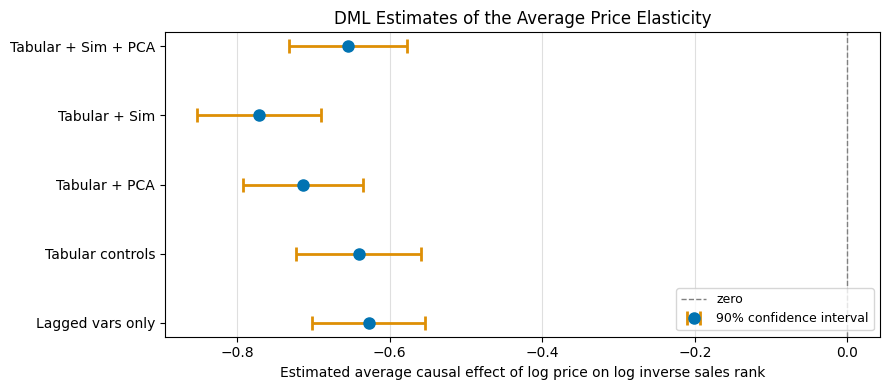

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(df_res))

ax.errorbar(
    x=df_res["theta"],
    y=y,
    xerr=[df_res["theta"] - df_res["ci_lo"],
          df_res["ci_hi"] - df_res["theta"]],
    fmt="o", color=palette[0], ecolor=palette[1],
    capsize=5, capthick=2, linewidth=2, markersize=8,
    label=f"{confidence_level*100:.0f}% confidence interval"
)
ax.axvline(0, color="gray", linestyle="--", linewidth=1, label="zero")
ax.set_yticks(y)
ax.set_yticklabels(df_res.index, fontsize=10)
ax.set_xlabel("Estimated average causal effect of log price on log inverse sales rank",
              fontsize=10)
ax.set_title("DML Estimates of the Average Price Elasticity", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Second-Stage Diagnostics

To build intuition, we inspect the partialled-out residuals and the second-stage regression for the preferred specification (tabular controls plus cluster similarities).

The scatter plot on the right shows that after removing variation explained by the state, there is a clear negative relationship between the price residual and the quantity residual. This is the signal the DML estimator uses to recover the causal effect.

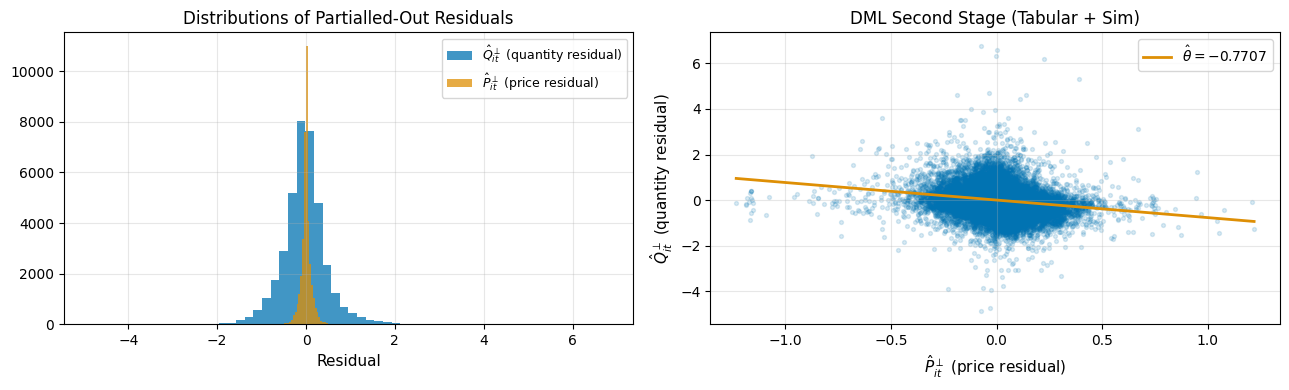

In [10]:
preferred_label = "Tabular + Sim"
preferred = next(r for r in results if r["label"] == preferred_label)
Q_perp    = preferred["Q_perp"]
P_perp    = preferred["P_perp"]
theta_hat = preferred["theta"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of residuals
axes[0].hist(Q_perp, bins=60, color=palette[0], alpha=0.75, edgecolor="none",
             label="$\\hat{Q}_{it}^\\perp$ (quantity residual)")
axes[0].hist(P_perp, bins=60, color=palette[1], alpha=0.75, edgecolor="none",
             label="$\\hat{P}_{it}^\\perp$ (price residual)")
axes[0].set_xlabel("Residual", fontsize=11)
axes[0].set_title("Distributions of Partialled-Out Residuals")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Second-stage scatter
axes[1].scatter(P_perp, Q_perp, alpha=0.15, s=8, color=palette[0])
p_grid = np.linspace(P_perp.min(), P_perp.max(), 100)
axes[1].plot(p_grid, theta_hat * p_grid, color=palette[1], lw=2,
             label=f"$\\hat{{\\theta}} = {theta_hat:.4f}$")
axes[1].set_xlabel("$\\hat{P}_{it}^\\perp$ (price residual)", fontsize=11)
axes[1].set_ylabel("$\\hat{Q}_{it}^\\perp$ (quantity residual)", fontsize=11)
axes[1].set_title("DML Second Stage (Tabular + Sim)")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

The estimated average causal effect is negative across all specifications, which is the expected sign: higher prices reduce the quantity sold. Because both $Q_{it}$ and $P_{it}$ are in logs, the coefficient $\hat{\theta}$ has an approximate elasticity interpretation. A value of $\hat{\theta} \approx -0.7$ means that a one percent increase in the buy-box price reduces the inverse sales rank by about 0.7 percent.

Note that the inverse sales rank is itself a transformation of demand. Under a power-law sales rank distribution, the implied demand elasticity is roughly twice as large in magnitude (see the paper for details), giving a demand elasticity in the range of $[-1.4, -1.0]$, which is economically plausible for consumer goods.

Two features of the results are reassuring. First, the estimates are stable across control specifications. Adding PCA or similarity controls does not change the estimate much, suggesting that the lagged variables already absorb most of the relevant confounding. Second, the confidence intervals are tight and do not include zero in any specification, so we can rule out a zero price effect with high confidence.

One potential threat to identification is a time-varying demand shock that simultaneously affects both price and quantity, such as a temporary surge in popularity that leads a seller to raise the price. The Markovian assumption rules this out given the state, but it cannot be tested directly. As a rough robustness check, the paper shows that a hidden confounder would need to explain around 15 percent of the residual variation in both equations to drive the estimate to zero, which seems unlikely given that the observed controls explain far less than that.